In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
workspace_root = str(Path.cwd().parent)
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

import numpy as np
from scipy.linalg import null_space
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram

from utils.statevector_viz import (
    get_data_amplitudes, print_statevector,
    plot_statevector_real_imag, plot_statevector_modulus_phase,
    sample_measurement_counts, print_measurement_counts
)

# Encoding $f(x)=x$ via Matrix Product States

**Target state:**
$$|\psi\rangle = \frac{1}{\mathcal{N}} \sum_{x=0}^{2^n-1} x\,|x\rangle, \qquad \mathcal{N} = \sqrt{\sum_x x^2}$$

## MPS Decomposition

Any $n$-qubit state can be written as a Matrix Product State:
$$|\psi\rangle = \sum_{s_1,\dots,s_n} A^{[1]s_1} A^{[2]s_2} \cdots A^{[n]s_n}\, |s_1 \dots s_n\rangle$$

where each $A^{[k]s_k}$ is a $\chi_{k-1}\times\chi_k$ matrix and $\chi_k$ is the **bond dimension** at cut $k$.

For $f(x) = x = \sum_k x_k 2^{k}$, the function is a sum of single-site terms, so the bond dimension is only **$\chi = 2$** (independent of $n$).

### Algorithm
1. **SVD chain**: Reshape the state vector and apply successive SVDs to extract left-canonical MPS tensors $A^{[k]}$ of shape $(\chi_L, 2, \chi_R)$.
2. **Isometry → Unitary**: Each left-canonical tensor defines an isometry. Extend it to a $4\times4$ unitary using the orthogonal complement (null space).
3. **Sequential circuit**: Apply each unitary to a **bond qubit** and the $k$-th physical qubit. After the last gate the bond qubit returns to $|0\rangle$.

In [2]:
def mps_decompose(psi, n):
    """Decompose a normalised state vector into right-canonical MPS tensors.

    SVDs sweep right-to-left so tensors satisfy:
        sum_s  B^s  B^{s dagger}  =  I      (right-canonical)

    This makes the map  |alpha_L> -> sum_{s,aR} B_{aL,s,aR} |aR,s>
    an isometry, which is what we need for left-to-right circuit construction.

    Returns
    -------
    tensors : list of np.ndarray
        tensors[k] has shape (chi_left, 2, chi_right).
        Site 0 = MSB, site n-1 = LSB  (MPS site k <-> Qiskit qubit n-1-k).
    """
    tensors = [None] * n
    remaining = psi.copy()
    chi_R = 1

    for k in range(n - 1, 0, -1):
        d_left = remaining.size // (2 * chi_R)
        M = remaining.reshape(d_left, 2 * chi_R)

        U, S, Vh = np.linalg.svd(M, full_matrices=False)

        chi_L = int(np.sum(S > 1e-12))
        U  = U[:, :chi_L]
        S  = S[:chi_L]
        Vh = Vh[:chi_L, :]

        tensors[k] = Vh.reshape(chi_L, 2, chi_R)
        remaining = U @ np.diag(S)
        chi_R = chi_L

    # first site — boundary tensor
    tensors[0] = remaining.reshape(1, 2, chi_R)
    return tensors


def mps_tensor_to_unitary(A, dim_bond):
    """Extend a right-canonical MPS tensor to a unitary gate matrix.

    Parameters
    ----------
    A        : ndarray, shape (chi_L, 2, chi_R)
    dim_bond : int  --  2**n_bond   (total bond Hilbert-space dimension)

    Returns
    -------
    U : ndarray, shape (2*dim_bond, 2*dim_bond)
        Rows/columns indexed as  phys * dim_bond + bond
        (matches Qiskit little-endian with qubits=[bond, phys]).
    """
    chi_L, d, chi_R = A.shape
    dim_total = d * dim_bond

    # Build isometry  V : (dim_total, chi_L)
    # Column alpha_L   ->   sum_{s,aR} A[aL,s,aR]  |s>|aR>
    V = np.zeros((dim_total, chi_L), dtype=complex)
    for alpha_L in range(chi_L):
        for s in range(d):
            for alpha_R in range(chi_R):
                V[s * dim_bond + alpha_R, alpha_L] = A[alpha_L, s, alpha_R]

    # Extend to square unitary via orthogonal complement
    if chi_L < dim_total:
        N = null_space(V.conj().T)
        U = np.hstack([V, N])
    else:
        U = V.copy()
    return U


def mps_circuit(psi, n):
    """Build a quantum circuit that prepares *psi* via its MPS decomposition.

    Layout:  data qubits 0 .. n-1,  bond qubit n   (bond = ancilla).

    Returns
    -------
    qc      : QuantumCircuit  (n + 1 qubits)
    tensors : list of MPS tensors
    """
    tensors = mps_decompose(psi, n)

    max_chi = max(max(t.shape[0], t.shape[2]) for t in tensors)
    n_bond   = int(np.ceil(np.log2(max(max_chi, 2))))
    dim_bond = 2 ** n_bond

    # data qubits 0..n-1  |  bond qubit n (highest index -> ancilla)
    qc = QuantumCircuit(n + n_bond)
    bond_qubits = list(range(n, n + n_bond))

    for k, A in enumerate(tensors):
        U = mps_tensor_to_unitary(A, dim_bond)
        phys_qubit = n - 1 - k        # MPS site k (MSB) -> Qiskit qubit n-1-k
        gate = UnitaryGate(U, label=f'MPS[{k}]')
        qc.append(gate, bond_qubits + [phys_qubit])
        qc.barrier()

    return qc, tensors

MPS bond dimensions:
  site 0:  shape (1, 2, 2)  (chi_L=1, chi_R=2)
  site 1:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
  site 2:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
  site 3:  shape (2, 2, 1)  (chi_L=2, chi_R=1)

Circuit: 5 qubits, 10 CX gates


global phase: 2.4907
                                                                »
q_0: ───────────────────────────────────────────────────────────»
                                                                »
q_1: ───────────────────────────────────────────────────────────»
                                                                »
q_2: ───────────────────────────────────────────────────────────»
     ┌───────────────────┐┌───┐┌──────────────────────────┐┌───┐»
q_3: ┤ U(0.95124,-π/2,0) ├┤ X ├┤ U(2.2992,2.4572,0.68435) ├┤ X ├»
     └─┬───────────────┬─┘└─┬─┘└─┬──────────────────────┬─┘└─┬─┘»
q_4: ──┤ U(3.0551,0,0) ├────■────┤ U(0.11895,-π/2,-π/2) ├────■──»
       └───────────────┘         └──────────────────────┘       »
«                                                             ░ »
«q_0: ────────────────────────────────────────────────────────░─»
«                                                             ░ »
«q_1: ────────────────────────────────────────────────────────░─»
«                                                             ░ »
«q_2: ────────────────────────────────────────────────────────░─»
«     ┌───────────────────────────┐┌───┐ ┌──────────────────┐ ░ »
«q_3: ┤ U(1.0795,0.85558,-2.7527) ├┤ X ├─┤ U(1.8526,0,-π/2) ├─░─»
«     └───┬───────────────────┬───┘└─┬─┘┌┴──────────────────┤ ░ »
«q_4: ────┤ U(0.11895,0,-π/2) ├──────■──┤ U(3.0551,-π,-π/2) ├─░─»
«         └───────────────────┘         └───────────────────┘ ░ »
«                                                                 »
«q_0: ────────────────────────────────────────────────────────────»
«                                                                 »
«q_1: ────────────────────────────────────────────────────────────»
«       ┌─────────────────┐  ┌───┐┌─────────────────────────┐┌───┐»
«q_2: ──┤ U(2.7073,π/2,0) ├──┤ X ├┤ U(1.8281,2.417,-2.1302) ├┤ X ├»
«       └─────────────────┘  └─┬─┘└─────────────────────────┘└─┬─┘»
«q_3: ─────────────────────────┼───────────────────────────────┼──»
«     ┌─────────────────────┐  │      ┌─────────────────┐      │  »
«q_4: ┤ U(π/2,0.76082,-π/2) ├──■──────┤ U(2.0805,0,π/2) ├──────■──»
«     └─────────────────────┘         └─────────────────┘         »
«                           ░                             »
«q_0: ──────────────────────░─────────────────────────────»
«                           ░   ┌─────────────────┐  ┌───┐»
«q_1: ──────────────────────░───┤ U(2.7321,π/2,0) ├──┤ X ├»
«     ┌───────────────────┐ ░   └─────────────────┘  └─┬─┘»
«q_2: ┤ U(0.23595,0,-π/2) ├─░──────────────────────────┼──»
«     └───────────────────┘ ░                          │  »
«q_3: ──────────────────────░──────────────────────────┼──»
«     ┌───────────────────┐ ░ ┌─────────────────────┐  │  »
«q_4: ┤ U(π/2,π/2,2.9216) ├─░─┤ U(π/2,0.91719,-π/2) ├──■──»
«     └───────────────────┘ ░ └─────────────────────┘     »
«                                                            ░ »
«q_0: ───────────────────────────────────────────────────────░─»
«     ┌──────────────────────────┐┌───┐┌───────────────────┐ ░ »
«q_1: ┤ U(1.8549,2.4604,-2.1538) ├┤ X ├┤ U(0.13887,0,-π/2) ├─░─»
«     └──────────────────────────┘└─┬─┘└───────────────────┘ ░ »
«q_2: ──────────────────────────────┼────────────────────────░─»
«                                   │                        ░ »
«q_3: ──────────────────────────────┼────────────────────────░─»
«         ┌─────────────────┐       │  ┌───────────────────┐ ░ »
«q_4: ────┤ U(2.0344,0,π/2) ├───────■──┤ U(π/2,π/2,3.0445) ├─░─»
«         └─────────────────┘          └───────────────────┘ ░ »
«     ┌──────────────────────┐┌───┐┌──────────────────────────┐┌───┐»
«q_0: ┤ U(2.525,π/2,-1.5932) ├┤ X ├┤ U(2.2992,2.4572,0.68435) ├┤ X ├»
«     └──────────────────────┘└─┬─┘└──────────────────────────┘└─┬─┘»
«q_1: ──────────────────────────┼────────────────────────────────┼──»
«                               │                                │  »
«q_2: ──────────────────────────┼─────────────────────


--- Prepared state ---
Statevector amplitudes (|basis⟩ : amplitude):
  |0001⟩ : 0.0284+0.0000j  (prob = 0.0008)
  |0010⟩ : 0.0568+0.0000j  (prob = 0.0032)
  |0011⟩ : 0.0852+0.0000j  (prob = 0.0073)
  |0100⟩ : 0.1136+0.0000j  (prob = 0.0129)
  |0101⟩ : 0.1420+0.0000j  (prob = 0.0202)
  |0110⟩ : 0.1704+0.0000j  (prob = 0.0290)
  |0111⟩ : 0.1988+0.0000j  (prob = 0.0395)
  |1000⟩ : 0.2272+0.0000j  (prob = 0.0516)
  |1001⟩ : 0.2556+0.0000j  (prob = 0.0653)
  |1010⟩ : 0.2840+0.0000j  (prob = 0.0806)
  |1011⟩ : 0.3124+0.0000j  (prob = 0.0976)
  |1100⟩ : 0.3408+0.0000j  (prob = 0.1161)
  |1101⟩ : 0.3692+0.0000j  (prob = 0.1363)
  |1110⟩ : 0.3976+0.0000j  (prob = 0.1581)
  |1111⟩ : 0.4260+0.0000j  (prob = 0.1815)

Fidelity with target: 1.0000000000
Measurement results (4096 shots):
  |0000⟩ :    0  
  |0001⟩ :    3  
  |0010⟩ :   11  
  |0011⟩ :   27  
  |0100⟩ :   54  
  |0101⟩ :   80  
  |0110⟩ :  132  █
  |0111⟩ :  159  █
  |1000⟩ :  243  ██
  |1001⟩ :  224  ██
  |1010⟩ :  339  ███
  |1011⟩

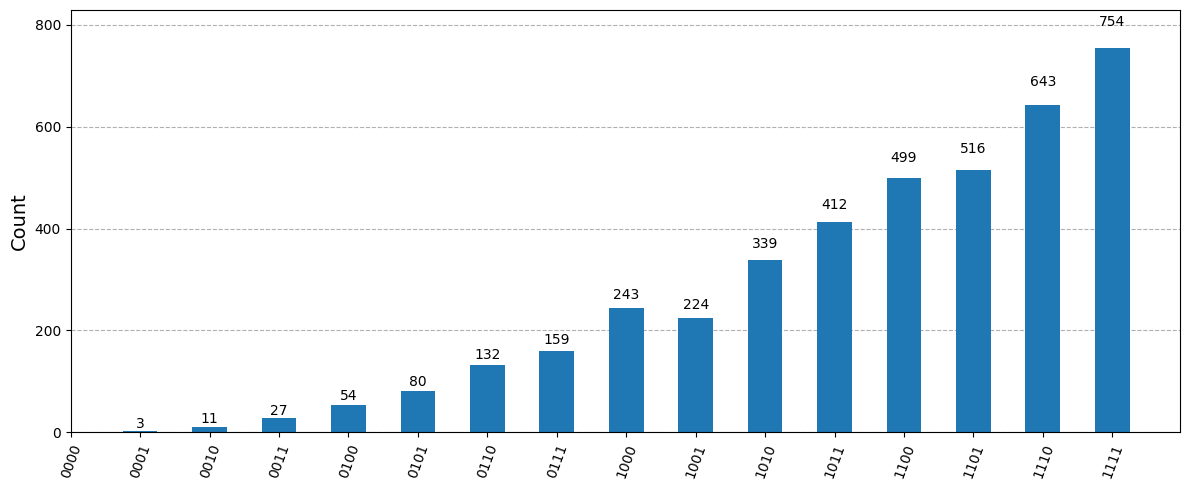

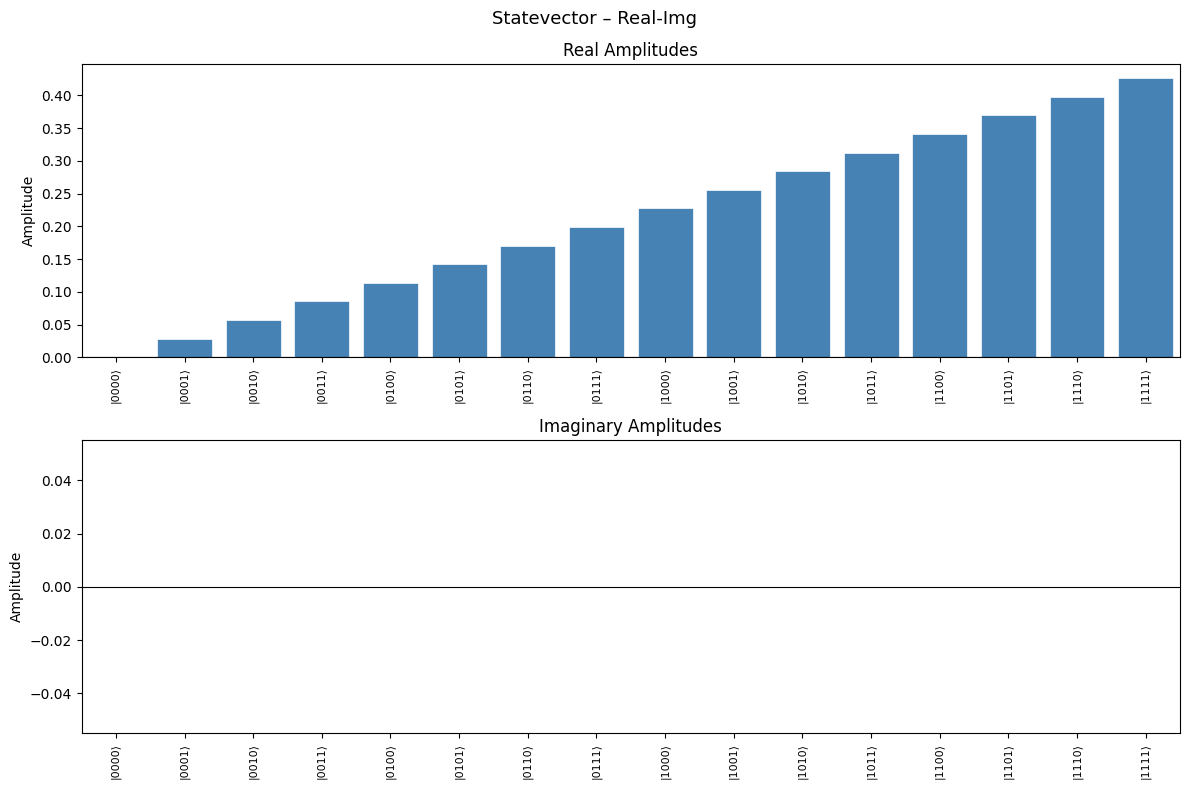

In [10]:
n_qubits = 4

# --- target state: |psi> = (1/N) sum_x  x |x> ---
dim = 2 ** n_qubits
target = np.array([x for x in range(dim)], dtype=complex)
target /= np.linalg.norm(target)

# --- MPS decomposition + circuit ---
qc, tensors = mps_circuit(target, n_qubits)

print("MPS bond dimensions:")
for k, A in enumerate(tensors):
    print(f"  site {k}:  shape {A.shape}  (chi_L={A.shape[0]}, chi_R={A.shape[2]})")

# --- transpile to basic gates ---
qc_t = transpile(qc, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_t.num_qubits} qubits, {qc_t.count_ops().get('cx', 0)} CX gates")
display(qc.decompose().draw())

# --- simulate and compare ---
data_amps = get_data_amplitudes(qc, n_qubits)

print("\n--- Prepared state ---")
print_statevector(data_amps, n_qubits)
fig = plot_statevector_real_imag(data_amps, n_qubits)

# --- fidelity check ---
fidelity = abs(np.vdot(target, data_amps)) ** 2
print(f"\nFidelity with target: {fidelity:.10f}")

# --- measurement histogram ---
shots = 4096
counts = sample_measurement_counts(qc, n_qubits, shots=shots)
print_measurement_counts(counts, shots)
plot_histogram(counts, figsize=(12, 5), bar_labels=True)

In [3]:
def analytical_mps_linear(n):
    """Construct MPS tensors for |psi> = (1/N) sum_x x|x> analytically.

    Bond dimension is exactly 2 for any n.
    Cost: O(n) — no exponential state vector needed.

    Tensor layout (MSB first):
        site 0  : shape (1, 2, 2)   — left boundary
        site k  : shape (2, 2, 2)   — interior
        site n-1: shape (2, 2, 1)   — right boundary
    """
    M = 2 ** n
    norm = np.sqrt((M - 1) * M * (2 * M - 1) / 6.0)

    if n == 1:
        # Trivial case: |psi> = |1>
        A = np.zeros((1, 2, 1))
        A[0, 1, 0] = 1.0
        return [A]

    tensors = []
    for k in range(n):
        w_k = 2 ** (n - 1 - k) / norm

        if k == 0:
            # Left boundary: absorb (1, 0) row vector
            A = np.zeros((1, 2, 2))
            A[0, 0, :] = [1.0, 0.0]
            A[0, 1, :] = [1.0, w_k]
        elif k == n - 1:
            # Right boundary: absorb (0, 1)^T column vector
            A = np.zeros((2, 2, 1))
            A[:, 0, 0] = [0.0, 1.0]
            A[:, 1, 0] = [w_k, 1.0]
        else:
            # Interior: upper-triangular transfer matrices
            A = np.zeros((2, 2, 2))
            A[:, 0, :] = np.eye(2)
            A[:, 1, :] = [[1.0, w_k], [0.0, 1.0]]

        tensors.append(A)
    return tensors


def right_canonicalize(tensors):
    """Bring MPS tensors into right-canonical form via a right-to-left QR sweep.

    After this, each tensor satisfies  sum_s A^s (A^s)† = I
    (rows of the matricised tensor are orthonormal), making
    the map  |alpha_L> -> sum_{s,aR} A[aL,s,aR] |s,aR>  an isometry.

    Cost: O(n) with constant-size matrix operations (at most 4x4).
    """
    n = len(tensors)
    rc = [t.copy().astype(complex) for t in tensors]

    for k in range(n - 1, 0, -1):
        chi_L, d, chi_R = rc[k].shape
        M = rc[k].reshape(chi_L, d * chi_R)   # shape (chi_L, d*chi_R)

        # LQ decomposition via QR of conjugate transpose
        # M^H = Q_qr R_qr  =>  M = R_qr^H Q_qr^H  =  L @ Q
        Q_qr, R_qr = np.linalg.qr(M.conj().T)
        L = R_qr.conj().T    # shape (chi_L, chi_new)
        Q = Q_qr.conj().T    # shape (chi_new, d*chi_R)

        chi_new = Q.shape[0]
        rc[k] = Q.reshape(chi_new, d, chi_R)

        # Absorb L into previous tensor
        pL, pd, pR = rc[k - 1].shape
        prev_mat = rc[k - 1].reshape(pL * pd, pR)
        rc[k - 1] = (prev_mat @ L).reshape(pL, pd, chi_new)

    return rc


def mps_circuit_from_tensors(tensors, n):
    """Build a quantum circuit from right-canonical MPS tensors.

    Layout:  data qubits 0..n-1  |  bond qubits n..n+n_bond-1
    """
    max_chi = max(max(t.shape[0], t.shape[2]) for t in tensors)
    n_bond  = int(np.ceil(np.log2(max(max_chi, 2))))
    dim_bond = 2 ** n_bond

    qc = QuantumCircuit(n + n_bond)
    bond_qubits = list(range(n, n + n_bond))

    for k, A in enumerate(tensors):
        U = mps_tensor_to_unitary(A, dim_bond)
        phys_qubit = n - 1 - k
        gate = UnitaryGate(U, label=f'MPS[{k}]')
        qc.append(gate, bond_qubits + [phys_qubit])

    return qc

Analytical MPS tensors (right-canonical):
  site 0:  shape (1, 2, 2)  (chi_L=1, chi_R=2)
           isometry error = 4.44e-16
  site 1:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 2.22e-16
  site 2:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 1.31e-16
  site 3:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 4.44e-16
  site 4:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 1.11e-16
  site 5:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 4.44e-16
  site 6:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
           isometry error = 4.44e-16
  site 7:  shape (2, 2, 1)  (chi_L=2, chi_R=1)
           isometry error = 0.00e+00

Circuit: 9 qubits, 17 CX gates


»
q_0: ──────────────────────────────────────────────────────────────────»
                                                                       »
q_1: ──────────────────────────────────────────────────────────────────»
                                                            ┌─────────┐»
q_2: ───────────────────────────────────────────────────────┤1        ├»
                                                 ┌─────────┐│         │»
q_3: ────────────────────────────────────────────┤1        ├┤         ├»
                                      ┌─────────┐│         ││         │»
q_4: ─────────────────────────────────┤1        ├┤         ├┤         ├»
                           ┌─────────┐│         ││         ││         │»
q_5: ──────────────────────┤1        ├┤         ├┤         ├┤  MPS[5] ├»
                ┌─────────┐│         ││         ││  MPS[4] ││         │»
q_6: ───────────┤1        ├┤         ├┤  MPS[3] ├┤         ├┤         ├»
     ┌─────────┐│         ││  MPS[2] ││         ││         ││         │»
q_7: ┤1        ├┤  MPS[1] ├┤         ├┤         ├┤         ├┤         ├»
     │  MPS[0] ││         ││         ││         ││         ││         │»
q_8: ┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├»
     └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘└─────────┘»
«                ┌─────────┐
«q_0: ───────────┤1        ├
«     ┌─────────┐│         │
«q_1: ┤1        ├┤         ├
«     │         ││         │
«q_2: ┤         ├┤         ├
«     │         ││         │
«q_3: ┤         ├┤         ├
«     │         ││         │
«q_4: ┤         ├┤  MPS[7] ├
«     │  MPS[6] ││         │
«q_5: ┤         ├┤         ├
«     │         ││         │
«q_6: ┤         ├┤         ├
«     │         ││         │
«q_7: ┤         ├┤         ├
«     │         ││         │
«q_8: ┤0        ├┤0        ├
«     └─────────┘└─────────┘


Fidelity vs exact target: 1.0000000000
Statevector amplitudes (|basis⟩ : amplitude):
  |00000001⟩ : 0.0004+0.0000j  (prob = 0.0000)
  |00000010⟩ : 0.0008+0.0000j  (prob = 0.0000)
  |00000011⟩ : 0.0013+0.0000j  (prob = 0.0000)
  |00000100⟩ : 0.0017+0.0000j  (prob = 0.0000)
  |00000101⟩ : 0.0021+0.0000j  (prob = 0.0000)
  |00000110⟩ : 0.0025+0.0000j  (prob = 0.0000)
  |00000111⟩ : 0.0030+0.0000j  (prob = 0.0000)
  |00001000⟩ : 0.0034+0.0000j  (prob = 0.0000)
  |00001001⟩ : 0.0038+0.0000j  (prob = 0.0000)
  |00001010⟩ : 0.0042+0.0000j  (prob = 0.0000)
  |00001011⟩ : 0.0047+0.0000j  (prob = 0.0000)
  |00001100⟩ : 0.0051+0.0000j  (prob = 0.0000)
  |00001101⟩ : 0.0055+0.0000j  (prob = 0.0000)
  |00001110⟩ : 0.0059+0.0000j  (prob = 0.0000)
  |00001111⟩ : 0.0064+0.0000j  (prob = 0.0000)
  |00010000⟩ : 0.0068+0.0000j  (prob = 0.0000)
  |00010001⟩ : 0.0072+0.0000j  (prob = 0.0001)
  |00010010⟩ : 0.0076+0.0000j  (prob = 0.0001)
  |00010011⟩ : 0.0081+0.0000j  (prob = 0.0001)
  |00010100⟩ : 0.0085

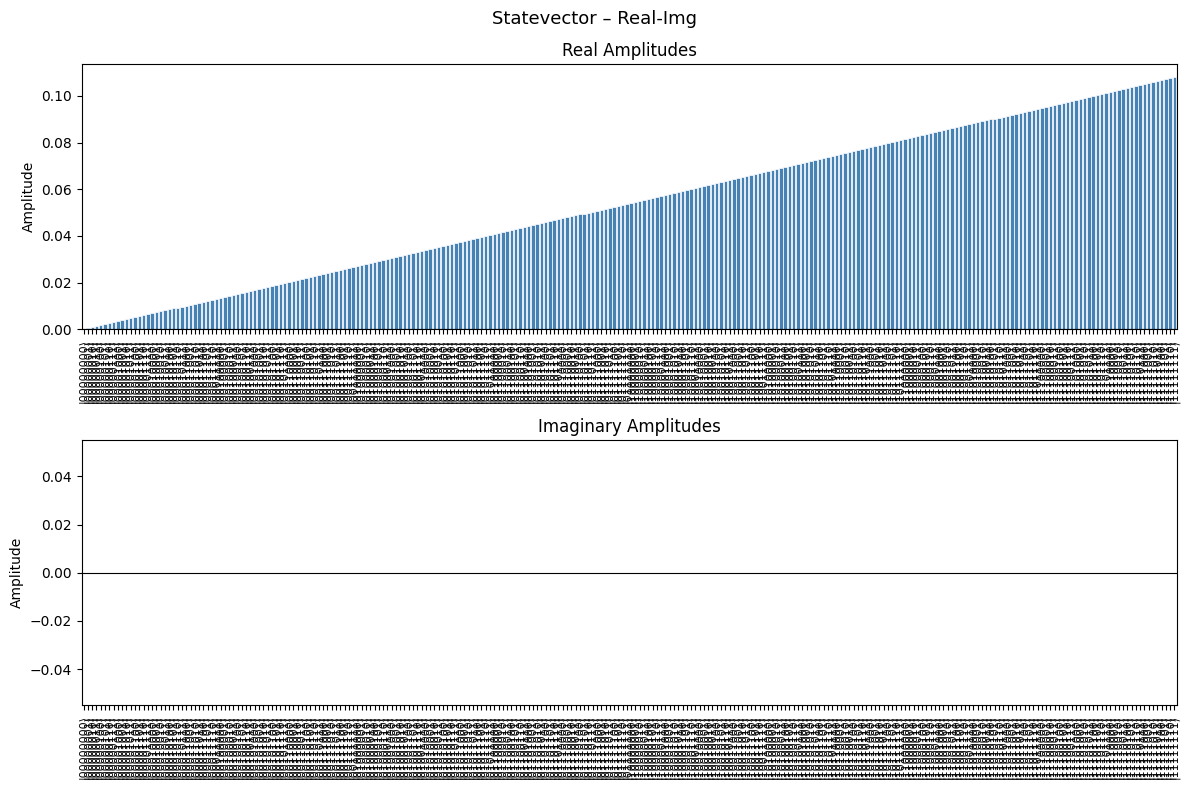

In [12]:
# --- Verify analytical MPS matches exact state for small n ---
n_test = 8

raw_tensors = analytical_mps_linear(n_test)
rc_tensors  = right_canonicalize(raw_tensors)

print("Analytical MPS tensors (right-canonical):")
for k, A in enumerate(rc_tensors):
    print(f"  site {k}:  shape {A.shape}  (chi_L={A.shape[0]}, chi_R={A.shape[2]})")

    # Verify isometry condition:  sum_s A^s (A^s)^dag = I
    M = A.reshape(A.shape[0], -1)
    eye_check = M @ M.conj().T
    err = np.max(np.abs(eye_check - np.eye(A.shape[0])))
    print(f"           isometry error = {err:.2e}")

# Build circuit from analytical tensors
qc_analytical = mps_circuit_from_tensors(rc_tensors, n_test)
qc_t = transpile(qc_analytical, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_t.num_qubits} qubits, {qc_t.count_ops().get('cx', 0)} CX gates")
display(qc_analytical.draw())

# Compare against exact target
dim = 2 ** n_test
target = np.array([x for x in range(dim)], dtype=complex)
target /= np.linalg.norm(target)

data_amps = get_data_amplitudes(qc_analytical, n_test)
fidelity = abs(np.vdot(target, data_amps)) ** 2
print(f"\nFidelity vs exact target: {fidelity:.10f}")
print_statevector(data_amps, n_test)
fig = plot_statevector_real_imag(data_amps, n_test)

In [13]:
# --- Scale to large n without computing 2^n amplitudes ---
import time

for n_large in [10, 20, 50, 100]:
    t0 = time.perf_counter()

    raw = analytical_mps_linear(n_large)
    rc  = right_canonicalize(raw)
    qc_large = mps_circuit_from_tensors(rc, n_large)
    qc_large_t = transpile(qc_large, basis_gates=['u', 'cx'], optimization_level=2)

    dt = time.perf_counter() - t0
    cx_count = qc_large_t.count_ops().get('cx', 0)
    print(f"n={n_large:>3d}:  {qc_large_t.num_qubits} qubits,  "
          f"{cx_count:>4d} CX gates,  built in {dt:.3f}s")

n= 10:  11 qubits,    21 CX gates,  built in 0.022s
n= 20:  21 qubits,    41 CX gates,  built in 0.027s
n= 50:  51 qubits,   101 CX gates,  built in 0.025s
n=100:  101 qubits,   201 CX gates,  built in 0.032s


## 2S Orbital: $f(x) = x \, e^{-x}$

**Target state:**
$$|\psi\rangle = \frac{1}{\mathcal{N}} \sum_{x=0}^{2^n-1} x \, e^{-\alpha x}\,|x\rangle, \qquad \mathcal{N} = \sqrt{\sum_x (x\,e^{-\alpha x})^2}$$

where $\alpha > 0$ is a decay parameter (controls how quickly the orbital falls off).

### Why bond dimension > 2?

Unlike $f(x) = x$, the exponential $e^{-\alpha x}$ introduces correlations between all qubits. Since $x = \sum_k s_k 2^{n-1-k}$:

$$e^{-\alpha x} = \prod_{k=0}^{n-1} e^{-\alpha \, s_k \, 2^{n-1-k}}$$

The exponential **factorises** as a product of single-site terms ($\chi = 1$), but the full function $x \cdot e^{-\alpha x}$ is a **product × sum**, which gives $\chi = 2$. Let's verify this numerically via SVD.

2S orbital  (n=4, alpha=0.5)
MPS bond dimensions:
  site 0:  shape (1, 2, 2)  (chi_L=1, chi_R=2)
  site 1:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
  site 2:  shape (2, 2, 2)  (chi_L=2, chi_R=2)
  site 3:  shape (2, 2, 1)  (chi_L=2, chi_R=1)

Circuit: 5 qubits, 11 CX gates


░             ░             ░ ┌─────────┐ ░ 
q_0: ────────────░─────────────░─────────────░─┤1        ├─░─
                 ░             ░ ┌─────────┐ ░ │         │ ░ 
q_1: ────────────░─────────────░─┤1        ├─░─┤         ├─░─
                 ░ ┌─────────┐ ░ │         │ ░ │         │ ░ 
q_2: ────────────░─┤1        ├─░─┤         ├─░─┤  MPS[3] ├─░─
     ┌─────────┐ ░ │         │ ░ │  MPS[2] │ ░ │         │ ░ 
q_3: ┤1        ├─░─┤  MPS[1] ├─░─┤         ├─░─┤         ├─░─
     │  MPS[0] │ ░ │         │ ░ │         │ ░ │         │ ░ 
q_4: ┤0        ├─░─┤0        ├─░─┤0        ├─░─┤0        ├─░─
     └─────────┘ ░ └─────────┘ ░ └─────────┘ ░ └─────────┘ ░


Fidelity: 1.0000000000
Statevector amplitudes (|basis⟩ : amplitude):
  |0001⟩ : 0.4297+0.0000j  (prob = 0.1847)
  |0010⟩ : 0.5213+0.0000j  (prob = 0.2717)
  |0011⟩ : 0.4743+0.0000j  (prob = 0.2249)
  |0100⟩ : 0.3835+0.0000j  (prob = 0.1471)
  |0101⟩ : 0.2908+0.0000j  (prob = 0.0846)
  |0110⟩ : 0.2116+0.0000j  (prob = 0.0448)
  |0111⟩ : 0.1498+0.0000j  (prob = 0.0224)
  |1000⟩ : 0.1038+0.0000j  (prob = 0.0108)
  |1001⟩ : 0.0708+0.0000j  (prob = 0.0050)
  |1010⟩ : 0.0477+0.0000j  (prob = 0.0023)
  |1011⟩ : 0.0318+0.0000j  (prob = 0.0010)
  |1100⟩ : 0.0211+0.0000j  (prob = 0.0004)
  |1101⟩ : 0.0138+0.0000j  (prob = 0.0002)
  |1110⟩ : 0.0090+0.0000j  (prob = 0.0001)
  |1111⟩ : 0.0059+0.0000j  (prob = 0.0000)
Measurement results (4096 shots):
  |0000⟩ :    0  
  |0001⟩ :  731  ███████
  |0010⟩ : 1105  ██████████
  |0011⟩ :  915  ████████
  |0100⟩ :  621  ██████
  |0101⟩ :  357  ███
  |0110⟩ :  198  █
  |0111⟩ :  103  █
  |1000⟩ :   35  
  |1001⟩ :   13  
  |1010⟩ :   11  
  |1011⟩ :    5  

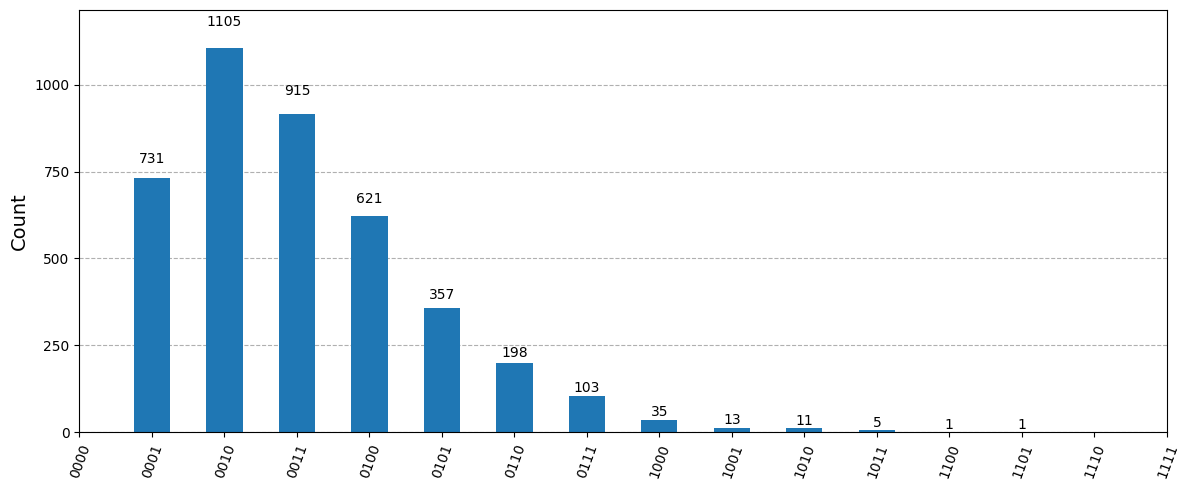

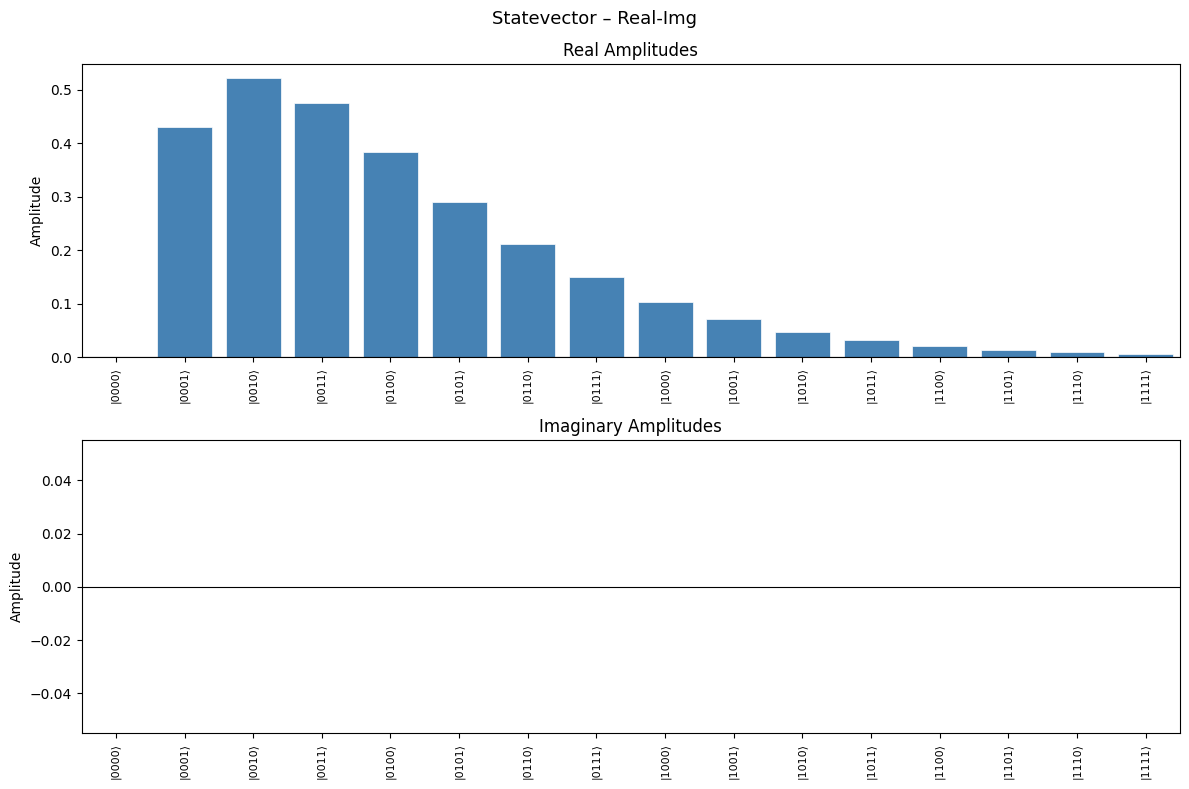

In [14]:
n_qubits = 4
alpha = 0.5  # decay parameter

dim = 2 ** n_qubits
target_2s = np.array([x * np.exp(-alpha * x) for x in range(dim)], dtype=complex)
target_2s /= np.linalg.norm(target_2s)

# --- SVD-based MPS decomposition ---
qc_2s, tensors_2s = mps_circuit(target_2s, n_qubits)

print(f"2S orbital  (n={n_qubits}, alpha={alpha})")
print(f"MPS bond dimensions:")
for k, A in enumerate(tensors_2s):
    print(f"  site {k}:  shape {A.shape}  (chi_L={A.shape[0]}, chi_R={A.shape[2]})")

qc_2s_t = transpile(qc_2s, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_2s_t.num_qubits} qubits, {qc_2s_t.count_ops().get('cx', 0)} CX gates")
display(qc_2s.draw())

# --- verify ---
data_amps_2s = get_data_amplitudes(qc_2s, n_qubits)
fidelity_2s = abs(np.vdot(target_2s, data_amps_2s)) ** 2
print(f"\nFidelity: {fidelity_2s:.10f}")
print_statevector(data_amps_2s, n_qubits)
fig = plot_statevector_real_imag(data_amps_2s, n_qubits)

# --- measurement ---
shots = 4096
counts_2s = sample_measurement_counts(qc_2s, n_qubits, shots=shots)
print_measurement_counts(counts_2s, shots)
plot_histogram(counts_2s, figsize=(12, 5), bar_labels=True)

In [15]:
# --- Study bond dimension vs n for the 2S orbital ---
print("Bond dimension profile for f(x) = x·exp(-alpha·x):\n")

for alpha_test in [0.1, 0.5, 1.0]:
    print(f"  alpha = {alpha_test}:")
    for n_test in [3, 4, 6, 8, 10]:
        dim = 2 ** n_test
        psi = np.array([x * np.exp(-alpha_test * x) for x in range(dim)], dtype=complex)
        norm = np.linalg.norm(psi)
        if norm < 1e-15:
            print(f"    n={n_test:>2d}:  state is zero")
            continue
        psi /= norm

        ts = mps_decompose(psi, n_test)
        chis = [ts[0].shape[2]] + [t.shape[2] for t in ts[1:]]
        max_chi = max(t.shape[0] for t in ts[1:])  # interior max chi_L
        max_chi = max(max_chi, max(t.shape[2] for t in ts[:-1]))
        print(f"    n={n_test:>2d}:  max bond dim = {max_chi},  "
              f"bond dims = {[t.shape[0] for t in ts]} -> {[t.shape[2] for t in ts]}")
    print()

Bond dimension profile for f(x) = x·exp(-alpha·x):

  alpha = 0.1:
    n= 3:  max bond dim = 2,  bond dims = [1, 2, 2] -> [2, 2, 1]
    n= 4:  max bond dim = 2,  bond dims = [1, 2, 2, 2] -> [2, 2, 2, 1]
    n= 6:  max bond dim = 2,  bond dims = [1, 2, 2, 2, 2, 2] -> [2, 2, 2, 2, 2, 1]
    n= 8:  max bond dim = 2,  bond dims = [1, 2, 2, 2, 2, 2, 2, 2] -> [2, 2, 2, 2, 2, 2, 2, 1]
    n=10:  max bond dim = 2,  bond dims = [1, 1, 2, 2, 2, 2, 2, 2, 2, 2] -> [1, 2, 2, 2, 2, 2, 2, 2, 2, 1]

  alpha = 0.5:
    n= 3:  max bond dim = 2,  bond dims = [1, 2, 2] -> [2, 2, 1]
    n= 4:  max bond dim = 2,  bond dims = [1, 2, 2, 2] -> [2, 2, 2, 1]
    n= 6:  max bond dim = 2,  bond dims = [1, 2, 2, 2, 2, 2] -> [2, 2, 2, 2, 2, 1]
    n= 8:  max bond dim = 2,  bond dims = [1, 1, 1, 2, 2, 2, 2, 2] -> [1, 1, 2, 2, 2, 2, 2, 1]
    n=10:  max bond dim = 2,  bond dims = [1, 1, 1, 1, 1, 2, 2, 2, 2, 2] -> [1, 1, 1, 1, 2, 2, 2, 2, 2, 1]

  alpha = 1.0:
    n= 3:  max bond dim = 2,  bond dims = [1, 2, 2] -> [2, 

## Analytical MPS for $f(x) = x\,e^{-\alpha x}$ — Scalable to Any $n$

### Factorization

Since $x = \sum_k s_k \cdot 2^{n-1-k}$ and $e^{-\alpha x} = \prod_k e^{-\alpha\,s_k\,2^{n-1-k}}$, the function $x \cdot e^{-\alpha x}$ is a product of a $\chi=2$ MPS (the sum) with a $\chi=1$ MPS (the product of exponentials). The result has $\chi = 2$.

Define $e_k = e^{-\alpha\,2^{n-1-k}}$ and $w_k = 2^{n-1-k}/\mathcal{N}$. The transfer matrices are:

$$A^{[k]0} = I_2, \qquad A^{[k]1} = e_k\begin{pmatrix}1 & w_k \\ 0 & 1\end{pmatrix}$$

For $s_k = 0$: identity (this bit contributes nothing). For $s_k = 1$: multiply by $e_k$ (exponential factor) and add $w_k$ to the running sum (upper-right entry). The product then gives:

$$(1,0)\,\prod_k A^{[k]s_k}\,(0,1)^T = e^{-\alpha x} \cdot \frac{x}{\mathcal{N}}$$

### $O(n)$ computation of $\mathcal{N}$

The norm $\mathcal{N}^2 = \sum_x (x\,e^{-\alpha x})^2$ is computed via MPS **transfer matrix contraction**: build a $4\times4$ transfer matrix $T_k = \sum_s A^s \otimes A^s$ at each site and multiply them together. This costs $O(n)$ with constant-size matrices.

In [16]:
def _norm_sq_xe_neg_ax(n, alpha):
    """Compute sum_{x=0}^{2^n-1} (x * exp(-alpha*x))^2  in O(n)
    via MPS transfer matrix contraction.

    The transfer matrix at site k is  T_k = sum_s  A^s (x) A^s  (Kronecker product)
    with A^0 = I_2 and A^1 = e_k * [[1, p_k],[0, 1]].

    T_k is 4x4, upper-triangular, allowing the full product in O(n).
    """
    # v_L = (1,0) x (1,0)  ->  (1,0,0,0)
    w = np.array([1.0, 0.0, 0.0, 0.0])

    for k in range(n):
        p = 2.0 ** (n - 1 - k)
        e2 = np.exp(-2 * alpha * p)     # e_k^2 = exp(-2*alpha*2^{n-1-k})

        # T_k = I_4  +  e_k^2 * (M_k kron M_k)
        # where M_k = [[1, p], [0, 1]]
        T = np.eye(4)
        T += e2 * np.array([
            [1,  p,  p,  p * p],
            [0,  1,  0,      p],
            [0,  0,  1,      p],
            [0,  0,  0,      1],
        ])
        w = w @ T

    # v_R = (0,1) x (0,1)  ->  (0,0,0,1)
    return w[3]


def analytical_mps_2s(n, alpha):
    """Construct MPS tensors for |psi> = (1/N) sum_x x*exp(-alpha*x) |x> analytically.

    Bond dimension is exactly 2 for any n and any alpha > 0.
    Cost: O(n) — no exponential state vector needed.

    Transfer matrices:
      A^{[k]0} = I_2                          (bit k is 0)
      A^{[k]1} = e_k * [[1, w_k], [0, 1]]    (bit k is 1)

    where e_k = exp(-alpha * 2^(n-1-k)) and w_k = 2^(n-1-k) / N.
    """
    norm_sq = _norm_sq_xe_neg_ax(n, alpha)
    norm = np.sqrt(norm_sq)

    if n == 1:
        e0 = np.exp(-alpha)
        A = np.zeros((1, 2, 1))
        A[0, 1, 0] = e0 / norm
        return [A]

    tensors = []
    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        e_k = np.exp(-alpha * p_k)
        w_k = p_k / norm

        if k == 0:
            # Left boundary: absorb (1, 0) row vector
            A = np.zeros((1, 2, 2))
            A[0, 0, :] = [1.0, 0.0]
            A[0, 1, :] = [e_k, e_k * w_k]
        elif k == n - 1:
            # Right boundary: absorb (0, 1)^T column vector
            A = np.zeros((2, 2, 1))
            A[:, 0, 0] = [0.0, 1.0]
            A[:, 1, 0] = [e_k * w_k, e_k]
        else:
            # Interior: e_k * upper-triangular for s=1, identity for s=0
            A = np.zeros((2, 2, 2))
            A[:, 0, :] = np.eye(2)
            A[:, 1, :] = [[e_k, e_k * w_k],
                          [0.0,        e_k]]

        tensors.append(A)
    return tensors

Analytical 2S MPS  (n=8, alpha=0.0375)
Tensors (right-canonical):
  site 0:  shape (1, 2, 2)  isometry err = 1.11e-16
  site 1:  shape (2, 2, 2)  isometry err = 4.44e-16
  site 2:  shape (2, 2, 2)  isometry err = 4.44e-16
  site 3:  shape (2, 2, 2)  isometry err = 1.11e-16
  site 4:  shape (2, 2, 2)  isometry err = 1.62e-17
  site 5:  shape (2, 2, 2)  isometry err = 3.33e-16
  site 6:  shape (2, 2, 2)  isometry err = 2.22e-16
  site 7:  shape (2, 2, 1)  isometry err = 0.00e+00

Circuit: 9 qubits, 17 CX gates


»
q_0: ──────────────────────────────────────────────────────────────────»
                                                                       »
q_1: ──────────────────────────────────────────────────────────────────»
                                                            ┌─────────┐»
q_2: ───────────────────────────────────────────────────────┤1        ├»
                                                 ┌─────────┐│         │»
q_3: ────────────────────────────────────────────┤1        ├┤         ├»
                                      ┌─────────┐│         ││         │»
q_4: ─────────────────────────────────┤1        ├┤         ├┤         ├»
                           ┌─────────┐│         ││         ││         │»
q_5: ──────────────────────┤1        ├┤         ├┤         ├┤  MPS[5] ├»
                ┌─────────┐│         ││         ││  MPS[4] ││         │»
q_6: ───────────┤1        ├┤         ├┤  MPS[3] ├┤         ├┤         ├»
     ┌─────────┐│         ││  MPS[2] ││         ││         ││         │»
q_7: ┤1        ├┤  MPS[1] ├┤         ├┤         ├┤         ├┤         ├»
     │  MPS[0] ││         ││         ││         ││         ││         │»
q_8: ┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├»
     └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘└─────────┘»
«                ┌─────────┐
«q_0: ───────────┤1        ├
«     ┌─────────┐│         │
«q_1: ┤1        ├┤         ├
«     │         ││         │
«q_2: ┤         ├┤         ├
«     │         ││         │
«q_3: ┤         ├┤         ├
«     │         ││         │
«q_4: ┤         ├┤  MPS[7] ├
«     │  MPS[6] ││         │
«q_5: ┤         ├┤         ├
«     │         ││         │
«q_6: ┤         ├┤         ├
«     │         ││         │
«q_7: ┤         ├┤         ├
«     │         ││         │
«q_8: ┤0        ├┤0        ├
«     └─────────┘└─────────┘


Fidelity vs exact target: 1.0000000000
Statevector amplitudes (|basis⟩ : amplitude):
  |00000001⟩ : 0.0140+0.0000j  (prob = 0.0002)
  |00000010⟩ : 0.0269+0.0000j  (prob = 0.0007)
  |00000011⟩ : 0.0389+0.0000j  (prob = 0.0015)
  |00000100⟩ : 0.0500+0.0000j  (prob = 0.0025)
  |00000101⟩ : 0.0602+0.0000j  (prob = 0.0036)
  |00000110⟩ : 0.0696+0.0000j  (prob = 0.0048)
  |00000111⟩ : 0.0782+0.0000j  (prob = 0.0061)
  |00001000⟩ : 0.0861+0.0000j  (prob = 0.0074)
  |00001001⟩ : 0.0933+0.0000j  (prob = 0.0087)
  |00001010⟩ : 0.0998+0.0000j  (prob = 0.0100)
  |00001011⟩ : 0.1058+0.0000j  (prob = 0.0112)
  |00001100⟩ : 0.1111+0.0000j  (prob = 0.0123)
  |00001101⟩ : 0.1160+0.0000j  (prob = 0.0134)
  |00001110⟩ : 0.1203+0.0000j  (prob = 0.0145)
  |00001111⟩ : 0.1241+0.0000j  (prob = 0.0154)
  |00010000⟩ : 0.1275+0.0000j  (prob = 0.0163)
  |00010001⟩ : 0.1305+0.0000j  (prob = 0.0170)
  |00010010⟩ : 0.1331+0.0000j  (prob = 0.0177)
  |00010011⟩ : 0.1353+0.0000j  (prob = 0.0183)
  |00010100⟩ : 0.1372

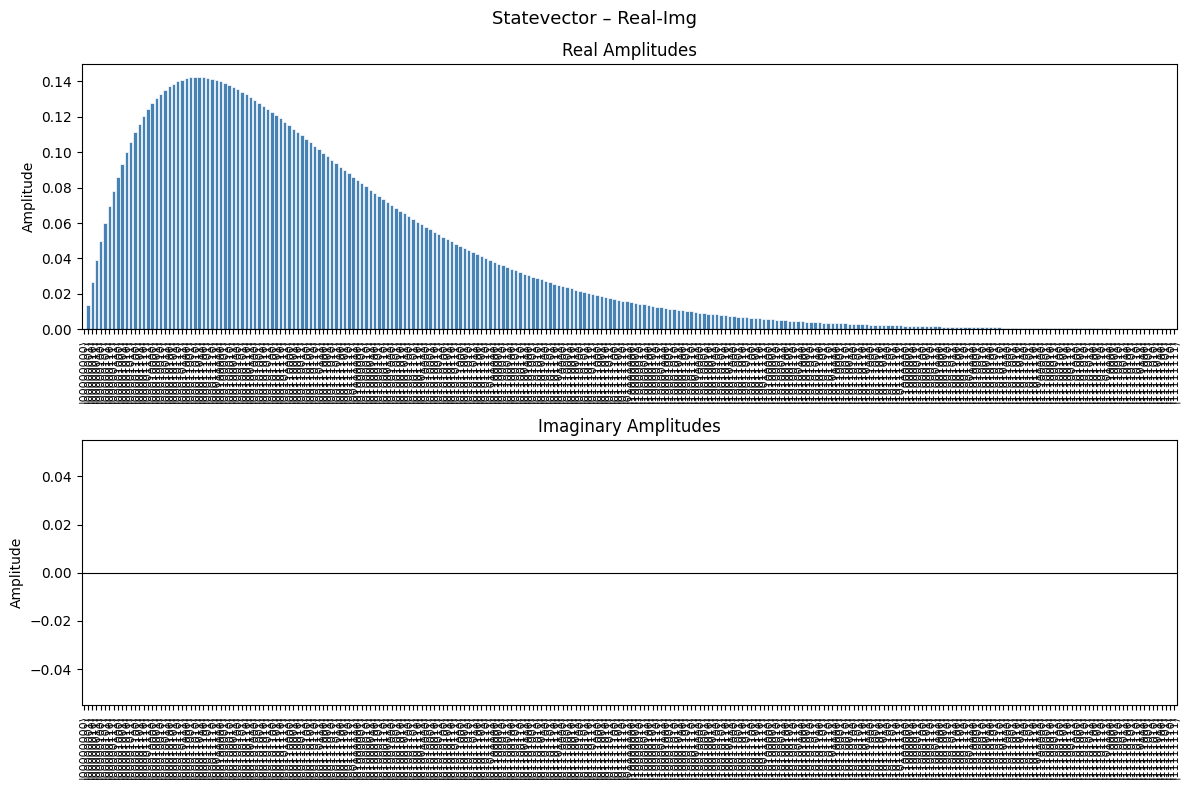

In [17]:
# --- Verify analytical 2S MPS against exact state for small n ---
n_test = 8
alpha = 0.0375

# Analytical construction (O(n), no 2^n vector)
raw_2s = analytical_mps_2s(n_test, alpha)
rc_2s  = right_canonicalize(raw_2s)

print(f"Analytical 2S MPS  (n={n_test}, alpha={alpha})")
print("Tensors (right-canonical):")
for k, A in enumerate(rc_2s):
    M = A.reshape(A.shape[0], -1)
    err = np.max(np.abs(M @ M.conj().T - np.eye(A.shape[0])))
    print(f"  site {k}:  shape {A.shape}  isometry err = {err:.2e}")

# Build circuit
qc_2s_ana = mps_circuit_from_tensors(rc_2s, n_test)
qc_2s_ana_t = transpile(qc_2s_ana, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_2s_ana_t.num_qubits} qubits, "
      f"{qc_2s_ana_t.count_ops().get('cx', 0)} CX gates")
display(qc_2s_ana.draw())

# Compare against exact target
dim = 2 ** n_test
target_exact = np.array([x * np.exp(-alpha * x) for x in range(dim)], dtype=complex)
target_exact /= np.linalg.norm(target_exact)

data_amps_ana = get_data_amplitudes(qc_2s_ana, n_test)
fidelity = abs(np.vdot(target_exact, data_amps_ana)) ** 2
print(f"\nFidelity vs exact target: {fidelity:.10f}")
print_statevector(data_amps_ana, n_test)
fig = plot_statevector_real_imag(data_amps_ana, n_test)

# Also verify norm computation
norm_analytical = np.sqrt(_norm_sq_xe_neg_ax(n_test, alpha))
norm_exact = np.linalg.norm([x * np.exp(-alpha * x) for x in range(dim)])
print(f"\nNorm check:  analytical = {norm_analytical:.10f},  exact = {norm_exact:.10f},  "
      f"diff = {abs(norm_analytical - norm_exact):.2e}")

In [18]:
# --- Scale 2S orbital to large n without computing 2^n amplitudes ---
import time

alpha = 0.5
print(f"f(x) = x·exp(-{alpha}·x)  —  analytical MPS construction\n")

for n_large in [10, 20, 50, 100, 200]:
    t0 = time.perf_counter()

    raw = analytical_mps_2s(n_large, alpha)
    rc  = right_canonicalize(raw)
    qc_large = mps_circuit_from_tensors(rc, n_large)
    qc_large_t = transpile(qc_large, basis_gates=['u', 'cx'], optimization_level=2)

    dt = time.perf_counter() - t0
    cx_count = qc_large_t.count_ops().get('cx', 0)
    max_chi = max(max(t.shape[0], t.shape[2]) for t in rc)
    print(f"n={n_large:>3d}:  {qc_large_t.num_qubits:>4d} qubits,  "
          f"{cx_count:>4d} CX gates,  max chi={max_chi},  built in {dt:.3f}s")

f(x) = x·exp(-0.5·x)  —  analytical MPS construction

n= 10:    11 qubits,    11 CX gates,  max chi=2,  built in 0.014s
n= 20:    21 qubits,    11 CX gates,  max chi=2,  built in 0.011s
n= 50:    51 qubits,    11 CX gates,  max chi=2,  built in 0.014s
n=100:   101 qubits,    11 CX gates,  max chi=2,  built in 0.022s
n=200:   201 qubits,    11 CX gates,  max chi=2,  built in 0.195s


## Hydrogen 2S Orbital: $f(x) = (2 - x/a)\,e^{-x/(2a)}$

**Target state:**
$$|\psi\rangle = \frac{1}{\mathcal{N}} \sum_{x=0}^{2^n-1} \left(2 - \frac{x}{a}\right) e^{-x/(2a)}\,|x\rangle$$

This is the radial part of the hydrogen 2S wavefunction. It has a **node** at $x = 2a$ where the amplitude changes sign — a feature absent from $x\,e^{-\alpha x}$.

### MPS Structure: $\chi = 3$

The function decomposes as:
$$f(x) = \underbrace{2\,e^{-x/(2a)}}_{\chi=1\text{ product}} - \underbrace{\frac{x}{a}\,e^{-x/(2a)}}_{\chi=2\text{ sum}\times\text{product}}$$

The direct sum gives an MPS with 3 bond states. Define $e_k = e^{-2^{n-1-k}/(2a)}$ and $p_k = 2^{n-1-k}$:

$$A^{[k]0} = I_3, \qquad A^{[k]1} = e_k\begin{pmatrix}1 & 0 & 0 \\ 0 & 1 & -p_k/a \\ 0 & 0 & 1\end{pmatrix}$$

With left boundary $(2, 1, 0)$ and right boundary $(1, 0, 1)^T$, the matrix product gives:

$$(2, 1, 0)\,\prod_k A^{[k]s_k}\,(1, 0, 1)^T = 2\,e^{-x/(2a)} - \frac{x}{a}\,e^{-x/(2a)} = f(x)$$

The norm is computed in $O(n)$ via $9\times9$ transfer matrix contraction ($\chi^2 = 9$).

In [6]:
def _norm_sq_2s_orbital(n, a):
    """Compute sum_{x=0}^{2^n-1} ((2 - x/a) * exp(-x/(2a)))^2 in O(n)
    via 9x9 transfer matrix contraction (chi=3, so chi^2=9).
    """
    l = np.array([2.0, 1.0, 0.0])
    r = np.array([1.0, 0.0, 1.0])

    v = np.kron(l, l)  # 9-dim left boundary vector

    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        e_k = np.exp(-p_k / (2.0 * a))

        N_k = e_k * np.array([
            [1.0, 0.0,        0.0],
            [0.0, 1.0, -p_k / a],
            [0.0, 0.0,        1.0],
        ])

        T_k = np.eye(9) + np.kron(N_k, N_k)
        v = v @ T_k

    return v @ np.kron(r, r)


def analytical_mps_2s_orbital(n, a):
    """Construct MPS tensors for |psi> = (1/N) sum_x (2-x/a)*exp(-x/(2a)) |x>.

    Bond dimension is exactly 3 for any n.
    Cost: O(n) — no exponential state vector needed.

    Transfer matrices (unnormalized):
        A^{[k]0} = I_3
        A^{[k]1} = e_k * [[1, 0, 0], [0, 1, -p_k/a], [0, 0, 1]]

    Left boundary: (2, 1, 0),  Right boundary: (1, 0, 1)^T
    Normalization absorbed into the left boundary.
    """
    norm = np.sqrt(_norm_sq_2s_orbital(n, a))

    if n == 1:
        e0 = np.exp(-1.0 / (2 * a))
        A = np.zeros((1, 2, 1))
        A[0, 0, 0] = 2.0 / norm
        A[0, 1, 0] = (2.0 - 1.0 / a) * e0 / norm
        return [A]

    tensors = []
    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        e_k = np.exp(-p_k / (2.0 * a))

        if k == 0:
            # Left boundary: absorb (2/N, 1/N, 0)
            A = np.zeros((1, 2, 3))
            A[0, 0, :] = [2.0 / norm, 1.0 / norm, 0.0]
            A[0, 1, :] = [2.0 * e_k / norm,
                          e_k / norm,
                          -e_k * p_k / (a * norm)]
        elif k == n - 1:
            # Right boundary: absorb (1, 0, 1)^T
            A = np.zeros((3, 2, 1))
            A[:, 0, 0] = [1.0, 0.0, 1.0]
            A[:, 1, 0] = [e_k, -e_k * p_k / a, e_k]
        else:
            # Interior: block-diagonal with off-diagonal coupling
            A = np.zeros((3, 2, 3))
            A[:, 0, :] = np.eye(3)
            A[:, 1, :] = [[e_k,  0.0,              0.0],
                          [0.0,  e_k, -e_k * p_k / a],
                          [0.0,  0.0,              e_k]]

        tensors.append(A)
    return tensors

Hydrogen 2S orbital  (n=8, a=30, node at x=60)
Tensors (right-canonical):
  site 0:  shape (1, 2, 3)  isometry err = 2.22e-16
  site 1:  shape (3, 2, 3)  isometry err = 4.44e-16
  site 2:  shape (3, 2, 3)  isometry err = 3.33e-16
  site 3:  shape (3, 2, 3)  isometry err = 6.66e-16
  site 4:  shape (3, 2, 3)  isometry err = 6.66e-16
  site 5:  shape (3, 2, 3)  isometry err = 6.66e-16
  site 6:  shape (3, 2, 2)  isometry err = 2.22e-16
  site 7:  shape (2, 2, 1)  isometry err = 1.61e-17

Circuit: 10 qubits, 140 CX gates


»
q_0: ──────────────────────────────────────────────────────────────────»
                                                                       »
q_1: ──────────────────────────────────────────────────────────────────»
                                                            ┌─────────┐»
q_2: ───────────────────────────────────────────────────────┤2        ├»
                                                 ┌─────────┐│         │»
q_3: ────────────────────────────────────────────┤2        ├┤         ├»
                                      ┌─────────┐│         ││         │»
q_4: ─────────────────────────────────┤2        ├┤         ├┤         ├»
                           ┌─────────┐│         ││         ││         │»
q_5: ──────────────────────┤2        ├┤         ├┤         ├┤         ├»
                ┌─────────┐│         ││         ││         ││  MPS[5] │»
q_6: ───────────┤2        ├┤         ├┤         ├┤  MPS[4] ├┤         ├»
     ┌─────────┐│         ││         ││  MPS[3] ││         ││         │»
q_7: ┤2        ├┤         ├┤  MPS[2] ├┤         ├┤         ├┤         ├»
     │         ││  MPS[1] ││         ││         ││         ││         │»
q_8: ┤0 MPS[0] ├┤0        ├┤0        ├┤0        ├┤0        ├┤0        ├»
     │         ││         ││         ││         ││         ││         │»
q_9: ┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├┤1        ├»
     └─────────┘└─────────┘└─────────┘└─────────┘└─────────┘└─────────┘»
«                ┌─────────┐
«q_0: ───────────┤2        ├
«     ┌─────────┐│         │
«q_1: ┤2        ├┤         ├
«     │         ││         │
«q_2: ┤         ├┤         ├
«     │         ││         │
«q_3: ┤         ├┤         ├
«     │         ││         │
«q_4: ┤         ├┤         ├
«     │         ││  MPS[7] │
«q_5: ┤  MPS[6] ├┤         ├
«     │         ││         │
«q_6: ┤         ├┤         ├
«     │         ││         │
«q_7: ┤         ├┤         ├
«     │         ││         │
«q_8: ┤0        ├┤0        ├
«     │         ││         │
«q_9: ┤1        ├┤1        ├
«     └─────────┘└─────────┘


Fidelity vs exact target: 1.0000000000
Statevector amplitudes (|basis⟩ : amplitude):
  |00000000⟩ : 0.2547+0.0000j  (prob = 0.0649)
  |00000001⟩ : 0.2463+0.0000j  (prob = 0.0607)
  |00000010⟩ : 0.2381+0.0000j  (prob = 0.0567)
  |00000011⟩ : 0.2301+0.0000j  (prob = 0.0530)
  |00000100⟩ : 0.2224+0.0000j  (prob = 0.0494)
  |00000101⟩ : 0.2148+0.0000j  (prob = 0.0461)
  |00000110⟩ : 0.2074+0.0000j  (prob = 0.0430)
  |00000111⟩ : 0.2002+0.0000j  (prob = 0.0401)
  |00001000⟩ : 0.1932+0.0000j  (prob = 0.0373)
  |00001001⟩ : 0.1863+0.0000j  (prob = 0.0347)
  |00001010⟩ : 0.1796+0.0000j  (prob = 0.0323)
  |00001011⟩ : 0.1731+0.0000j  (prob = 0.0300)
  |00001100⟩ : 0.1668+0.0000j  (prob = 0.0278)
  |00001101⟩ : 0.1606+0.0000j  (prob = 0.0258)
  |00001110⟩ : 0.1546+0.0000j  (prob = 0.0239)
  |00001111⟩ : 0.1487+0.0000j  (prob = 0.0221)
  |00010000⟩ : 0.1430+0.0000j  (prob = 0.0205)
  |00010001⟩ : 0.1375+0.0000j  (prob = 0.0189)
  |00010010⟩ : 0.1321+0.0000j  (prob = 0.0174)
  |00010011⟩ : 0.1268

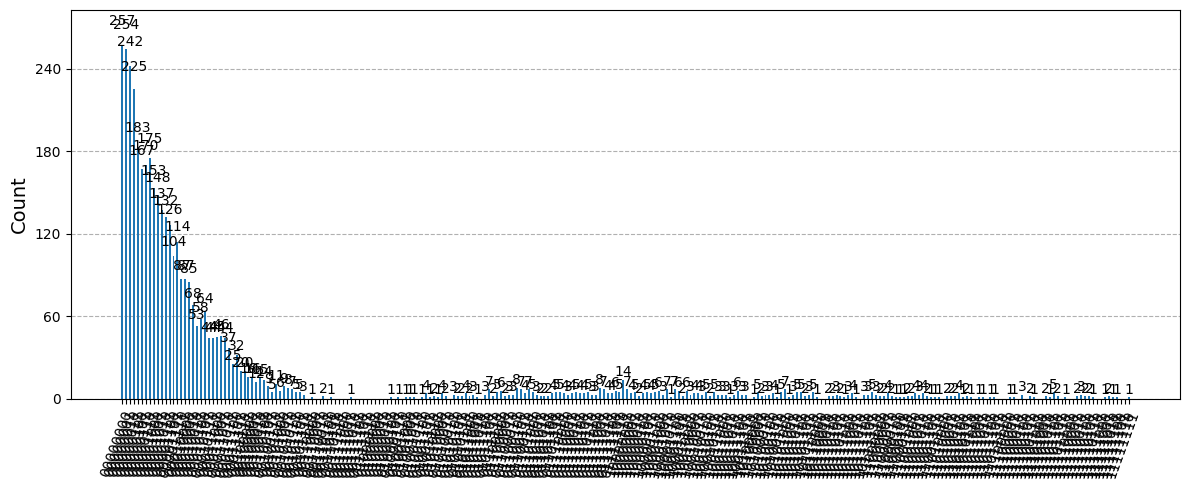

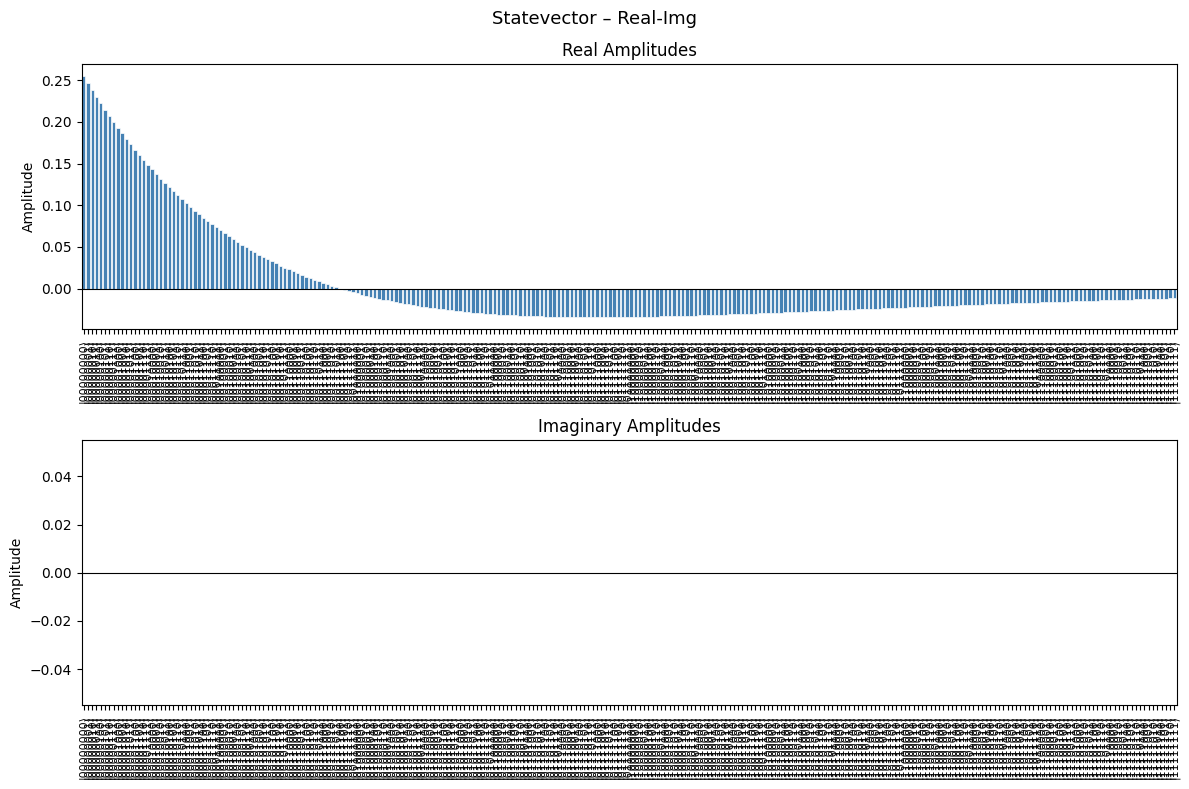

In [7]:
# --- Verify hydrogen 2S orbital for small n ---
n_qubits = 8
a_param = 30   # node at x = 2a = 60

# Analytical MPS construction
raw_2s_orb = analytical_mps_2s_orbital(n_qubits, a_param)
rc_2s_orb  = right_canonicalize(raw_2s_orb)

print(f"Hydrogen 2S orbital  (n={n_qubits}, a={a_param}, node at x={2*a_param})")
print("Tensors (right-canonical):")
for k, A in enumerate(rc_2s_orb):
    M = A.reshape(A.shape[0], -1)
    err = np.max(np.abs(M @ M.conj().T - np.eye(A.shape[0])))
    print(f"  site {k}:  shape {A.shape}  isometry err = {err:.2e}")

# Build circuit
qc_2s_orb = mps_circuit_from_tensors(rc_2s_orb, n_qubits)
qc_2s_orb_t = transpile(qc_2s_orb, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_2s_orb_t.num_qubits} qubits, "
      f"{qc_2s_orb_t.count_ops().get('cx', 0)} CX gates")
display(qc_2s_orb.draw())

# Compare against exact target
dim = 2 ** n_qubits
target_exact = np.array([(2 - x / a_param) * np.exp(-x / (2 * a_param))
                          for x in range(dim)], dtype=complex)
target_exact /= np.linalg.norm(target_exact)

data_amps_orb = get_data_amplitudes(qc_2s_orb, n_qubits)
fidelity = abs(np.vdot(target_exact, data_amps_orb)) ** 2
print(f"\nFidelity vs exact target: {fidelity:.10f}")
print_statevector(data_amps_orb, n_qubits)
fig = plot_statevector_real_imag(data_amps_orb, n_qubits)

# Norm check
norm_analytical = np.sqrt(_norm_sq_2s_orbital(n_qubits, a_param))
norm_exact = np.linalg.norm([(2 - x / a_param) * np.exp(-x / (2 * a_param))
                              for x in range(dim)])
print(f"\nNorm check:  analytical = {norm_analytical:.10f},  exact = {norm_exact:.10f},  "
      f"diff = {abs(norm_analytical - norm_exact):.2e}")

# Measurement
shots = 4096
counts_orb = sample_measurement_counts(qc_2s_orb, n_qubits, shots=shots)
print_measurement_counts(counts_orb, shots)
plot_histogram(counts_orb, figsize=(12, 5), bar_labels=True)

In [41]:
from utils.real_hardware import print_ibm_fez_analysis

n_qubits = 8
a_param = 0.0375

# Analytical construction (O(n), no 2^n vector)
raw_2s = analytical_mps_2s(n_qubits, a_param)
rc_2s  = right_canonicalize(raw_2s)
qc = mps_circuit_from_tensors(rc_2s, n_qubits)


# raw_2s = analytical_mps_2s_orbital(n_qubits, a_param)
# rc  = right_canonicalize(raw_2s)
# qc = mps_circuit_from_tensors(rc, n_qubits)

r = print_ibm_fez_analysis(qc, optimization_level=3)

print(raw_2s[3])

  IBM Fez (156-qubit Heron R2) – Circuit Analysis
  Original circuit:  9 qubits,  depth 8
  Transpiled circuit: depth 95
  Two-qubit (CZ) gates:  27
  Single-qubit gates:    136
  Total gates:           163
  Gate breakdown:        {'sx': 77, 'rz': 55, 'cz': 27, 'x': 4}
[[[1.         0.        ]
  [0.54881164 0.12753237]]

 [[0.         1.        ]
  [0.         0.54881164]]]


## Hydrogen 2S Orbital with Jacobian: $f(r) = r\,(2 - r/a)\,e^{-r/(2a)}$

**Target state:**
$$|\psi\rangle = \frac{1}{\mathcal{N}} \sum_{r=0}^{2^n-1} r\left(2 - \frac{r}{a}\right) e^{-r/(2a)}\,|r\rangle = \frac{1}{\mathcal{N}} \sum_{r} \left(2r - \frac{r^2}{a}\right) e^{-r/(2a)}\,|r\rangle$$

The Jacobian factor $r$ (from the spherical volume element $r^2 dr$ — one $r$ is in $R_{2S}$ itself, the other from the integration measure) turns the polynomial from degree 1 to degree 2.

The node is still at $r = 2a$.

### MPS Structure: $\chi = 3$ (quadratic running sum)

The function $f(r) = (2r - r^2/a)\,e^{-r/(2a)}$ is a **degree-2 polynomial × exponential product**. The three bond states track the running polynomial:
- **State 0**: constant term (1)
- **State 1**: linear running sum ($x = \sum s_j p_j$)
- **State 2**: quadratic running sum ($x^2 = (\sum s_j p_j)^2$)

Define $e_k = e^{-p_k/(2a)}$ and $p_k = 2^{n-1-k}$. The transfer matrices are:

$$A^{[k]0} = I_3, \qquad A^{[k]1} = e_k\begin{pmatrix}1 & p_k & p_k^2 \\ 0 & 1 & 2p_k \\ 0 & 0 & 1\end{pmatrix}$$

With left boundary $\ell = (1, 0, 0)/\mathcal{N}$ and right boundary $r = (0, 2, -1/a)^T$:

$$\ell\,\prod_k A^{[k]s_k}\,r = \frac{1}{\mathcal{N}} e^{-x/(2a)}(2x - x^2/a)$$

The norm is computed in $O(n)$ via $9\times9$ transfer matrix contraction.

In [9]:
def _norm_sq_2s_jacobian(n, a):
    """Compute sum_{r=0}^{2^n-1} (r*(2-r/a)*exp(-r/(2a)))^2  in O(n)
    via 9x9 transfer matrix contraction (chi=3, so chi^2=9).

    Uses the quadratic running-sum transfer matrices:
        A^0 = I_3,  A^1 = e_k * [[1, p_k, p_k^2], [0, 1, 2*p_k], [0, 0, 1]]
    with left boundary (1, 0, 0) and right boundary (0, 2, -1/a).
    """
    l = np.array([1.0, 0.0, 0.0])
    r = np.array([0.0, 2.0, -1.0 / a])

    v = np.kron(l, l)  # 9-dim left boundary vector

    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        e_k = np.exp(-p_k / (2.0 * a))

        N_k = e_k * np.array([
            [1.0,  p_k,  p_k * p_k],
            [0.0,  1.0,  2.0 * p_k],
            [0.0,  0.0,        1.0],
        ])

        T_k = np.eye(9) + np.kron(N_k, N_k)
        v = v @ T_k

    return v @ np.kron(r, r)


def analytical_mps_2s_jacobian(n, a):
    """Construct MPS tensors for |psi> = (1/N) sum_r r*(2-r/a)*exp(-r/(2a)) |r>.

    Bond dimension is exactly 3 for any n.
    Cost: O(n) — no exponential state vector needed.

    The three bond states track the quadratic running sum:
        state 0: constant (1)
        state 1: linear sum x = sum_j s_j p_j
        state 2: quadratic sum x^2

    Transfer matrices:
        A^{[k]0} = I_3
        A^{[k]1} = e_k * [[1, p_k, p_k^2], [0, 1, 2*p_k], [0, 0, 1]]

    Left boundary: (1, 0, 0) / N
    Right boundary: (0, 2, -1/a)^T
    """
    norm = np.sqrt(_norm_sq_2s_jacobian(n, a))

    if n == 1:
        e0 = np.exp(-1.0 / (2 * a))
        A = np.zeros((1, 2, 1))
        A[0, 0, 0] = 0.0  # f(0) = 0
        A[0, 1, 0] = (2.0 - 1.0 / a) * e0 / norm  # f(1) = 1*(2-1/a)*e^{-1/(2a)}
        return [A]

    tensors = []
    for k in range(n):
        p_k = 2.0 ** (n - 1 - k)
        e_k = np.exp(-p_k / (2.0 * a))

        if k == 0:
            # Left boundary: absorb (1/N, 0, 0)
            A = np.zeros((1, 2, 3))
            A[0, 0, :] = [1.0 / norm, 0.0, 0.0]
            A[0, 1, :] = [e_k / norm,
                          e_k * p_k / norm,
                          e_k * p_k * p_k / norm]
        elif k == n - 1:
            # Right boundary: absorb (0, 2, -1/a)^T
            A = np.zeros((3, 2, 1))
            A[:, 0, 0] = [0.0, 2.0, -1.0 / a]
            A[:, 1, 0] = [e_k * (2.0 * p_k - p_k * p_k / a),
                          e_k * (2.0 - 2.0 * p_k / a),
                          -e_k / a]
        else:
            # Interior: upper-triangular for s=1, identity for s=0
            A = np.zeros((3, 2, 3))
            A[:, 0, :] = np.eye(3)
            A[:, 1, :] = [[e_k, e_k * p_k,      e_k * p_k * p_k],
                          [0.0,       e_k,      e_k * 2.0 * p_k],
                          [0.0,       0.0,                  e_k]]

        tensors.append(A)
    return tensors

Hydrogen 2S with Jacobian  (n=4, a=3.0, node at r=6.0)
f(r) = r*(2-r/a)*exp(-r/(2a))

Tensors (right-canonical):
  site 0:  shape (1, 2, 3)  isometry err = 3.33e-16
  site 1:  shape (3, 2, 3)  isometry err = 5.55e-16
  site 2:  shape (3, 2, 2)  isometry err = 6.66e-16
  site 3:  shape (2, 2, 1)  isometry err = 0.00e+00

Circuit: 6 qubits, 74 CX gates


┌─────────┐
q_0: ─────────────────────────────────┤2        ├
                           ┌─────────┐│         │
q_1: ──────────────────────┤2        ├┤         ├
                ┌─────────┐│         ││         │
q_2: ───────────┤2        ├┤         ├┤         ├
     ┌─────────┐│         ││         ││  MPS[3] │
q_3: ┤2        ├┤         ├┤  MPS[2] ├┤         ├
     │         ││  MPS[1] ││         ││         │
q_4: ┤0 MPS[0] ├┤0        ├┤0        ├┤0        ├
     │         ││         ││         ││         │
q_5: ┤1        ├┤1        ├┤1        ├┤1        ├
     └─────────┘└─────────┘└─────────┘└─────────┘


Fidelity vs exact target: 1.0000000000
Statevector amplitudes (|basis⟩ : amplitude):
  |0001⟩ : 0.1556+0.0000j  (prob = 0.0242)
  |0010⟩ : 0.2108+0.0000j  (prob = 0.0444)
  |0011⟩ : 0.2007+0.0000j  (prob = 0.0403)
  |0100⟩ : 0.1510+0.0000j  (prob = 0.0228)
  |0101⟩ : 0.0799+0.0000j  (prob = 0.0064)
  |0111⟩ : -0.0801+0.0000j  (prob = 0.0064)
  |1000⟩ : -0.1551+0.0000j  (prob = 0.0240)
  |1001⟩ : -0.2215+0.0000j  (prob = 0.0491)
  |1010⟩ : -0.2778+0.0000j  (prob = 0.0772)
  |1011⟩ : -0.3233+0.0000j  (prob = 0.1045)
  |1100⟩ : -0.3583+0.0000j  (prob = 0.1283)
  |1101⟩ : -0.3833+0.0000j  (prob = 0.1469)
  |1110⟩ : -0.3993+0.0000j  (prob = 0.1595)
  |1111⟩ : -0.4074+0.0000j  (prob = 0.1660)

Norm check:  analytical = 9.0663097509,  exact = 9.0663097509,  diff = 5.33e-15
Measurement results (4096 shots):
  |0000⟩ :    0  
  |0001⟩ :   99  
  |0010⟩ :  175  █
  |0011⟩ :  166  █
  |0100⟩ :   86  
  |0101⟩ :   23  
  |0110⟩ :    0  
  |0111⟩ :   30  
  |1000⟩ :   97  
  |1001⟩ :  202  █
  |10

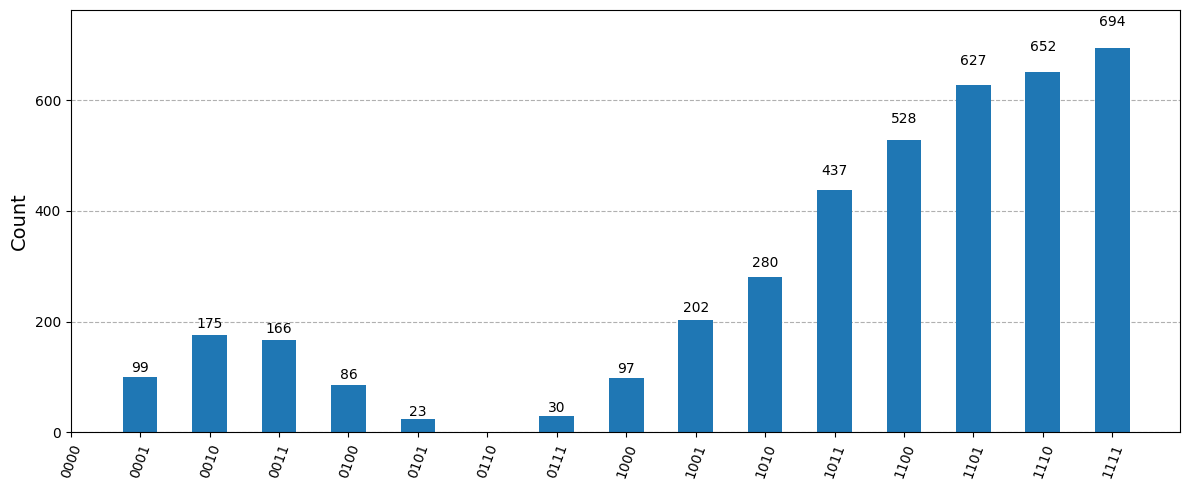

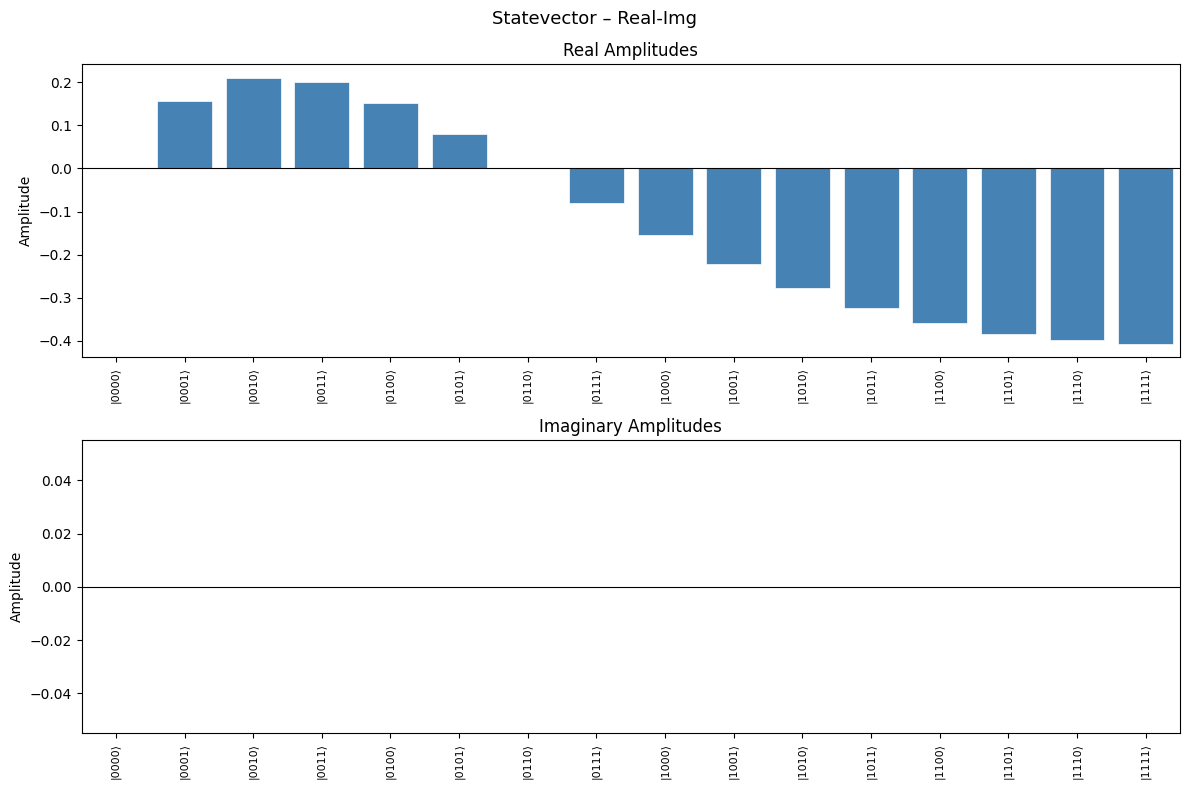

In [10]:
# --- Verify hydrogen 2S orbital with Jacobian for small n ---
n_qubits = 4
a_param = 3.0   # node at r = 2a = 6

# Analytical MPS construction
raw_2s_jac = analytical_mps_2s_jacobian(n_qubits, a_param)
rc_2s_jac  = right_canonicalize(raw_2s_jac)

print(f"Hydrogen 2S with Jacobian  (n={n_qubits}, a={a_param}, node at r={2*a_param})")
print(f"f(r) = r*(2-r/a)*exp(-r/(2a))")
print("\nTensors (right-canonical):")
for k, A in enumerate(rc_2s_jac):
    M = A.reshape(A.shape[0], -1)
    err = np.max(np.abs(M @ M.conj().T - np.eye(A.shape[0])))
    print(f"  site {k}:  shape {A.shape}  isometry err = {err:.2e}")

# Build circuit
qc_2s_jac = mps_circuit_from_tensors(rc_2s_jac, n_qubits)
qc_2s_jac_t = transpile(qc_2s_jac, basis_gates=['u', 'cx'], optimization_level=2)
print(f"\nCircuit: {qc_2s_jac_t.num_qubits} qubits, "
      f"{qc_2s_jac_t.count_ops().get('cx', 0)} CX gates")
display(qc_2s_jac.draw())

# Compare against exact target: f(r) = r*(2-r/a)*exp(-r/(2a))
dim = 2 ** n_qubits
target_exact = np.array([r * (2 - r / a_param) * np.exp(-r / (2 * a_param))
                          for r in range(dim)], dtype=complex)
target_exact /= np.linalg.norm(target_exact)

data_amps_jac = get_data_amplitudes(qc_2s_jac, n_qubits)
fidelity = abs(np.vdot(target_exact, data_amps_jac)) ** 2
print(f"\nFidelity vs exact target: {fidelity:.10f}")
print_statevector(data_amps_jac, n_qubits)
fig = plot_statevector_real_imag(data_amps_jac, n_qubits)

# Norm check
norm_analytical = np.sqrt(_norm_sq_2s_jacobian(n_qubits, a_param))
norm_exact = np.linalg.norm([r * (2 - r / a_param) * np.exp(-r / (2 * a_param))
                              for r in range(dim)])
print(f"\nNorm check:  analytical = {norm_analytical:.10f},  exact = {norm_exact:.10f},  "
      f"diff = {abs(norm_analytical - norm_exact):.2e}")

# Measurement
shots = 4096
counts_jac = sample_measurement_counts(qc_2s_jac, n_qubits, shots=shots)
print_measurement_counts(counts_jac, shots)
plot_histogram(counts_jac, figsize=(12, 5), bar_labels=True)

In [11]:
# --- Scale Jacobian 2S to large n ---
import time

a_scale = 3.0
print(f"f(r) = r·(2-r/{a_scale})·exp(-r/{2*a_scale})  —  analytical MPS (Jacobian)\n")

for n_large in [10, 20, 50, 100, 200]:
    t0 = time.perf_counter()

    raw = analytical_mps_2s_jacobian(n_large, a_scale)
    t_mps = time.perf_counter() - t0

    rc  = right_canonicalize(raw)
    qc_large = mps_circuit_from_tensors(rc, n_large)
    qc_large_t = transpile(qc_large, basis_gates=['u', 'cx'], optimization_level=2)

    dt = time.perf_counter() - t0
    cx_count = qc_large_t.count_ops().get('cx', 0)
    max_chi = max(max(t.shape[0], t.shape[2]) for t in rc)
    print(f"n={n_large:>3d}:  {qc_large_t.num_qubits:>4d} qubits,  "
          f"{cx_count:>4d} CX gates,  max chi={max_chi},  "
          f"MPS built in {t_mps:.4f}s,  total {dt:.3f}s")

f(r) = r·(2-r/3.0)·exp(-r/6.0)  —  analytical MPS (Jacobian)

n= 10:    12 qubits,   173 CX gates,  max chi=3,  MPS built in 0.0005s,  total 0.097s
n= 20:    22 qubits,   229 CX gates,  max chi=3,  MPS built in 0.0007s,  total 0.123s
n= 50:    52 qubits,   229 CX gates,  max chi=3,  MPS built in 0.0016s,  total 0.129s
n=100:   102 qubits,   229 CX gates,  max chi=3,  MPS built in 0.0030s,  total 0.145s
n=200:   202 qubits,   229 CX gates,  max chi=3,  MPS built in 0.0061s,  total 0.177s


1D 2S fidelity: 1.0000000000
